# RDKit Module 04: Molecular Operations

## Part:1 Manipulating Molecular Structures Using RDKit

## Learning Objectives

By the end of this notebook, you will be able to:

- Add explicit hydrogen atoms
- Remove explicit hydrogen atoms
- Understand implicit vs explicit hydrogens
- Create editable molecules (RWMol)
- Add atoms
- Remove atoms
- Add bonds
- Remove bonds
- Atom Indices in RDKit
- Combine multiple molecules

# Implicity vs Explicity Hydrogens 

In [14]:
 from rdkit import Chem
from rdkit.Chem import Draw

In [6]:
mol=Chem.MolFromSmiles('CCO')

In [10]:
print(Chem.MolToSmiles(mol))

CCO


## Intuition: Why are Hydrogens Hidden?

When chemists draw molecules on paper, hydrogen atoms attached to carbon are often omitted because they are implied by carbon's valence.

RDKit follows the same philosophy.

Instead of storing every hydrogen atom explicitly, RDKit stores them implicitly to:

- Reduce memory usage
- Speed up computations
- Simplify molecular representations
- Improve descriptor and fingerprint calculations

Hydrogens are added explicitly only when they are required, such as:

- 3D conformer generation
- Molecular docking
- Force-field optimization

In [12]:
# Implicit Hydrogen
mol=Chem.MolFromSmiles('CCO')
mol.GetNumAtoms()
# Hydrogens are hidden 

3

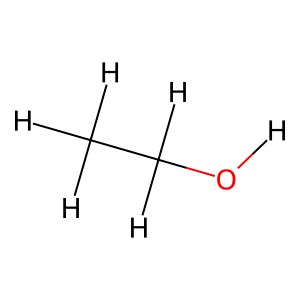

In [15]:
# Explicit Hydrogen
mol_h=Chem.AddHs(mol)
Draw.MolToImage(mol_h)
# Now Every hydrogen becomes an atom.

In [17]:
# check number of atoms:
mol_h.GetNumAtoms()

9

In [20]:
# Removing Hydrogens
mol=Chem.RemoveHs(mol_h)
print(Chem.MolToSmiles(mol))

CCO


# Part 2: Editable Molecules (RWMol)

## Why Do We Need Editable Molecules?

After creating a molecule, we often need to modify its structure.

For example:

- Add a fluorine atom
- Remove a methyl group
- Replace oxygen with sulfur
- Create molecular analogues
- Generate virtual libraries

However, RDKit does not allow direct modification of a standard Mol object.

Instead, we must first convert it into an editable molecule called RWMol (Read-Write Molecule).

Understanding RWMol is essential for molecular editing and cheminformatics workflows.

## Intuition Behind Editable Molecules

Imagine you receive a PDF document.

You can read it.

You can search it.

You can print it.

But you cannot edit its contents directly.

To make changes, you first convert it into a Word document.

After editing, you can save it again as a PDF.

RDKit follows a similar philosophy.

A Mol object behaves like a read-only document.

It is designed for safe analysis.

When structural modifications are needed, RDKit requires converting it into an editable RWMol object.

After editing, the RWMol can be converted back into a standard Mol object.

## What is RWMol?

RWMol stands for Read-Write Molecule.

Unlike a Mol object, an RWMol object supports structural modifications.

Using RWMol, we can:

- Add atoms
- Remove atoms
- Add bonds
- Remove bonds
- Replace atoms
- Modify bond types

Once editing is complete, the RWMol can be converted back into a standard Mol object.

In [1]:
# example
from rdkit import Chem
mol=Chem.MolFromSmiles('CCO')
# convert to RWMol
rw_mol=Chem.RWMol(mol)
# check the type
type(rw_mol)

rdkit.Chem.rdchem.RWMol

In [3]:
# convert back to Mol
edited_mol=rw_mol.GetMol()
#check
type(edited_mol)

rdkit.Chem.rdchem.Mol

RWMol is commonly used for:

• Lead optimization

• Bioisostere design

• Scaffold modification

• Virtual library generation

• Reaction enumeration

• Fragment-based drug design

# Part_03 Adding and Removing Atoms

## Why Add or Remove Atoms?

Medicinal chemists rarely use molecules exactly as they are.

During lead optimization, atoms are frequently added, removed, or replaced to improve:

- Potency
- Selectivity
- Solubility
- Metabolic stability
- Toxicity profile

RDKit allows these structural modifications using the RWMol class.

## Atom Editing in RDKit

Atom editing is performed on an RWMol object.

Common atom operations include:

- AddAtom()
- RemoveAtom()
- ReplaceAtom()

After editing, the molecule should be converted back to a Mol object and sanitized before further analysis.

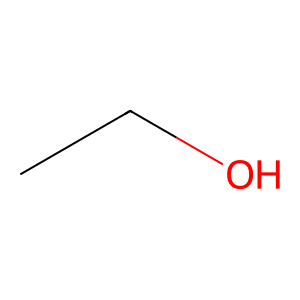

In [4]:
# example

from rdkit import Chem
from rdkit.Chem import Draw
mol=Chem.MolFromSmiles('CCO')
Draw.MolToImage(mol)

In [5]:
# Convert to Editable Molecule

rw_mol=Chem.RWMol(mol)

In [6]:
# add flourine atom
flourine= Chem.Atom('F')
#add it
new_atom=rw_mol.AddAtom(flourine)
print(new_atom)

3


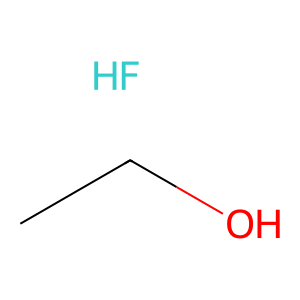

In [8]:
Draw.MolToImage(rw_mol)

# The fluorine does not appear connected to the molecule.
Why?
Because adding an atom does not automatically create a bond.
An atom without a bond is just an isolated atom inside the molecule object.
This naturally leads to the next concept:
Atoms and bonds are independent objects in RDKit.

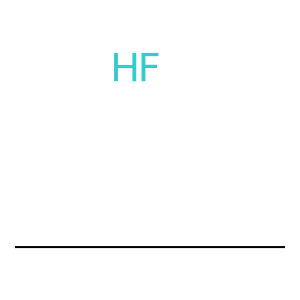

In [9]:
# Remove an Atom: Remove the oxygen atom (index2)

rw_mol.RemoveAtom(2)

# convert back to a Mol Object
edited=rw_mol.GetMol()
Draw.MolToImage(edited)

How did the structure change?
Why is sanitization important after removing atoms?

# Part 04 Adding and Removing Bonds

## Bond Editing in RDKit

Bond editing can only be performed using an RWMol object.

Common bond operations include:

- AddBond()
- RemoveBond()

Bond types include:

- SINGLE
- DOUBLE
- TRIPLE
- AROMATIC

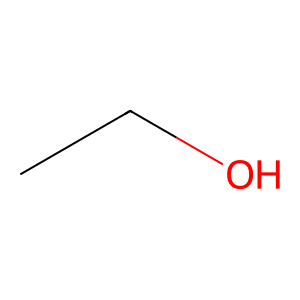

In [11]:
# example
# create ethanol
from rdkit import Chem
from rdkit.Chem import Draw
mol=Chem.MolFromSmiles('CCO')
Draw.MolToImage(mol)



In [12]:
#step: 2 Convert to RWMol
rw_mol=Chem.RWMol(mol)

In [14]:
#step:3 Add Flourine Atom
flourine=Chem.Atom('F')
f_index=rw_mol.AddAtom(flourine)
print(f_index)

3


#step:4 Connect flourine to carbon
#carbon atom index=1
#flourine atom index=3
rw_mol.AddBond(1,3,Chem.BondType.SINGLE)

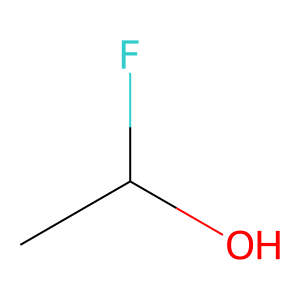

In [17]:
#step:5 Convert back to Mol
edited=rw_mol.GetMol()
Chem.SanitizeMol(edited)
Draw.MolToImage(edited)

# Part:5 Atom Indices in RDKit

## Why Do Atom Indices Matter?

RDKit identifies every atom in a molecule using a unique integer called the atom index.

When modifying molecules, RDKit does not ask for atom names like Carbon or Oxygen.

Instead, it requires the atom index.

Functions such as:

- AddBond()
- RemoveBond()
- RemoveAtom()
- ReplaceAtom()

all operate using atom indices.

Therefore, understanding atom indexing is essential before learning molecular editing.

In [18]:
from rdkit import Chem

mol = Chem.MolFromSmiles("CCO")

for atom in mol.GetAtoms():
    print(
        atom.GetIdx(),
        atom.GetSymbol()
    )

0 C
1 C
2 O


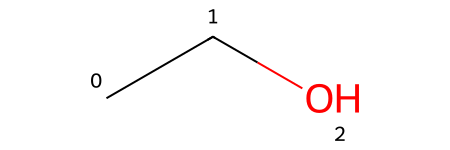

In [19]:
from rdkit.Chem.Draw import IPythonConsole

IPythonConsole.drawOptions.addAtomIndices = True

mol

In [20]:
# find Oxygen Atom
for atom in mol.GetAtoms():

    if atom.GetSymbol()=="O":

        print(atom.GetIdx())

2


## 💡 Pro Tip

When working with large drug molecules (50–100 atoms), never guess atom indices.

Always visualize them using:

IPythonConsole.drawOptions.addAtomIndices = True

This is the standard practice when editing complex molecules in RDKit.

# Part: Combining Molecules

## Why Combine Molecules?

In drug discovery, scientists often work with molecular fragments rather than complete drug molecules.

Examples include:

- Fragment-Based Drug Discovery (FBDD)
- Linker Design
- Molecular Library Generation
- PROTAC Design
- Reaction Product Generation

RDKit allows multiple molecules to be combined into a single molecular object, providing the foundation for constructing larger chemical structures.

## Combining Molecules in RDKit

RDKit provides the CombineMols() function.

This function merges two molecules into a single molecule object.

However, the molecules remain disconnected.

To create a chemically meaningful structure, a bond must be added afterward using RWMol.

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw

In [3]:
# Example

ethanol=Chem.MolFromSmiles('CCO')
benzene=Chem.MolFromSmiles('c1ccccc1')

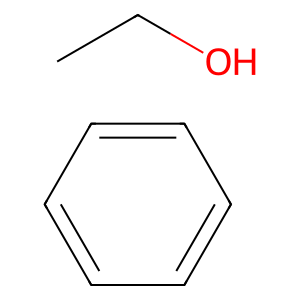

In [6]:
# combine them
combined=Chem.CombineMols(ethanol,benzene)
Draw.MolToImage(combined)
# you Will see ethanol and benzene displayed together, but they are not connected. 

In [7]:
# print atom Count
print(combined.GetNumAtoms())

9


In [8]:
# Convert to editable molecule
rw=Chem.RWMol(combined)

# Now you are ready to connect the fragment by adding a bond.